<a href="https://colab.research.google.com/github/sreenathsnv/AI-ML/blob/DL/DeepLearning_pt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning** #5

## Gradient Descent Algorithm ( Revised)

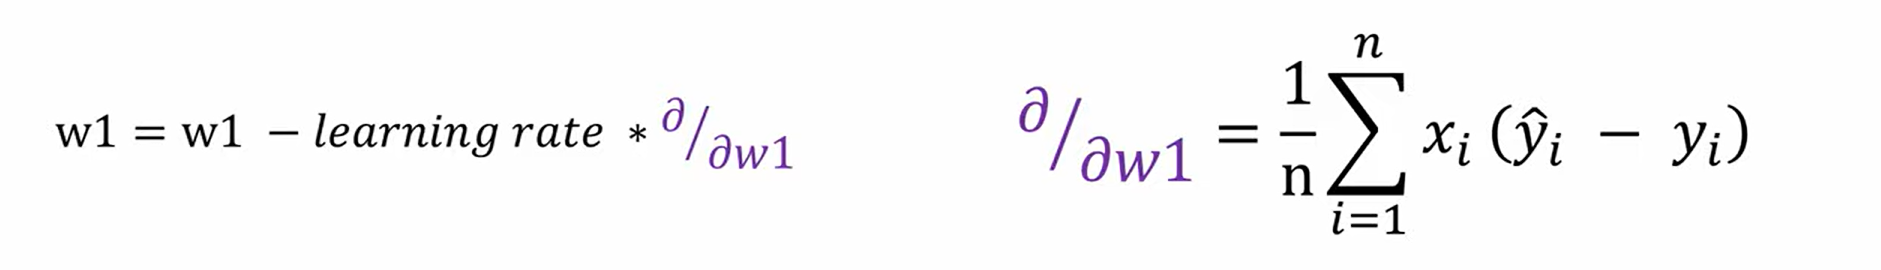

**The xi is obtained by derivating the mse wrt to w where yp = w1xi+b**
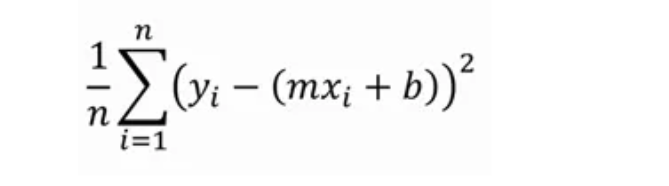

** similarly **

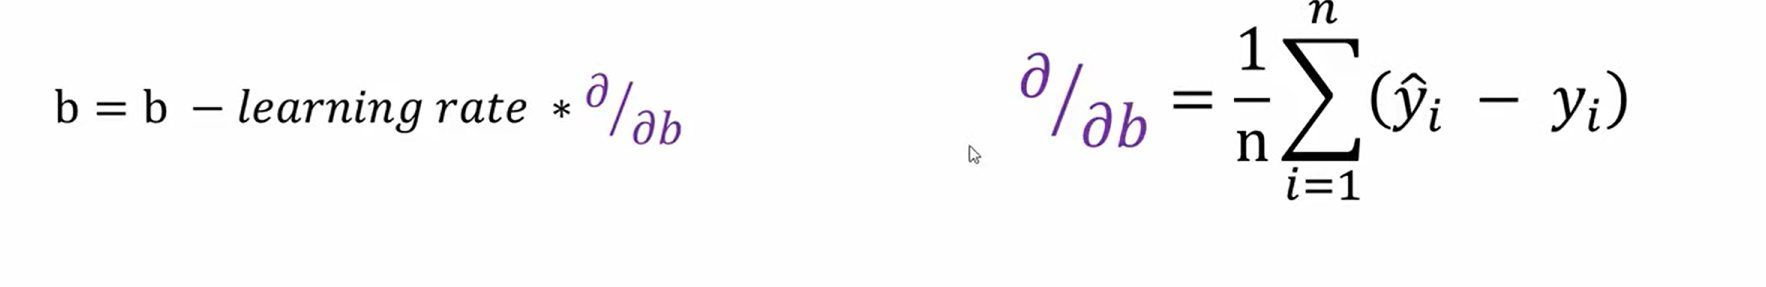

## Code implementation

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from tensorflow import keras

In [18]:
import pandas as pd

data = [
    [22,1,0],
    [25,0,0],
    [47,1,1],
    [52,0,0],
    [46,1,1],
    [56,1,1],
    [55,0,0],
    [60,0,1],
    [62,1,1],
    [61,1,1],
    [18,1,0],
    [28,1,0],
    [27,0,0],
    [29,0,0],
    [49,1,1],
    [55,1,1],
    [25,0,1],
    [58,1,1],
    [19,0,0],
    [18,1,0],
    [21,1,0],
    [26,0,0],
    [40,1,1],
    [45,1,1],
    [50,1,1],
    [54,1,1],
    [23,1,0],
    [46,1,0]
]

df = pd.DataFrame(data, columns=["age", "affordibility", "bought_insurance"])

print(df)

    age  affordibility  bought_insurance
0    22              1                 0
1    25              0                 0
2    47              1                 1
3    52              0                 0
4    46              1                 1
5    56              1                 1
6    55              0                 0
7    60              0                 1
8    62              1                 1
9    61              1                 1
10   18              1                 0
11   28              1                 0
12   27              0                 0
13   29              0                 0
14   49              1                 1
15   55              1                 1
16   25              0                 1
17   58              1                 1
18   19              0                 0
19   18              1                 0
20   21              1                 0
21   26              0                 0
22   40              1                 1
23   45         

In [19]:
df.shape

(28, 3)

In [20]:
from numpy.random.mtrand import random
from sklearn.model_selection import train_test_split

X = df.drop("bought_insurance", axis=1)
y = df["bought_insurance"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.22,random_state=42)

In [21]:
X_scaled = X_train.copy()
X_scaled['age'] = X_scaled['age'] / 100

In [25]:
X_test_scaled = X_test.copy()
X_test_scaled['age'] = X_test_scaled['age'] / 100

In [23]:
model = keras.Sequential([
    keras.layers.Dense(units=1,input_shape=(2,),activation='sigmoid',kernel_initializer='ones',bias_initializer='zeros')]
                         )
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_scaled,y_train,epochs=5000)

Epoch 1/5000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8571 - loss: 0.5762
Epoch 2502/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8571 - loss: 0.5762
Epoch 2503/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8571 - loss: 0.5761
Epoch 2504/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8571 - loss: 0.5761
Epoch 2505/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8571 - loss: 0.5761
Epoch 2506/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8571 - loss: 0.5760
Epoch 2507/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8571 - loss: 0.5760
Epoch 2508/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8571 - loss: 0.5760
Epoch 2509/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8571 - loss: 0.5759
Epoch 2510/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8571 - loss: 0.5759
Epoch 2511/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8571 - loss: 0

In [26]:
model.evaluate(X_test_scaled,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.2746


[0.27459344267845154, 1.0]

In [28]:
coef, intercept = model.get_weights()
coef,intercept

(array([[4.7809567],
        [1.1193382]], dtype=float32),
 array([-2.6674352], dtype=float32))

In [29]:
def fix_log_input(arr,epsilon=1e-15):

  arr = [max(i,epsilon) for i in arr]
  arr = [min(i,1-epsilon) for i in arr]
  return arr

def log_loss(y_true,y_predicted):
  y_true =fix_log_input(y_true)
  y_predicted =fix_log_input(y_predicted)

  total_error = 0
  for yt,yp in zip(y_true,y_predicted):
    total_error += yt*np.log(yp) + (1-yt)*np.log(1-yp)
  return -(total_error/len(y_true))

In [37]:
def sigmoid(x):
        import math
        import numpy as np # Import numpy
        return 1 / (1 + np.exp(-x)) # Use np.exp for element-wise operation

In [45]:
def gradient_descent(age,affordibility,y_true,epochs,loss_threshold=None,lr=0.05):
  # w1,w2,bias
  w1=w2=1
  bias = 0

  for i in range(epochs):
    weighted_sum = w1*age + w2*affordibility + bias
    y_predicted = sigmoid(weighted_sum)

    loss = log_loss(y_true,y_predicted)

    w1 = w1 - lr*(np.mean(age*(y_predicted-y_true)))
    w2 = w2 - lr*(np.mean(affordibility*(y_predicted-y_true)))
    bias = bias - lr*(np.mean(y_predicted - y_true))

    print(f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

    if loss_threshold and ( loss > loss_threshold):
      break
  return w1,w2,bias



In [46]:
gradient_descent(X_scaled['age'],X_scaled['affordibility'],y_train,1000,loss_threshold=0.5090)

Epoch:0, w1:0.9970078467222739, w2:0.9924055052404634, bias:-0.01271508146524136, loss:0.7692831630607848


(np.float64(0.9970078467222739),
 np.float64(0.9924055052404634),
 np.float64(-0.01271508146524136))

## Custom Neural Network Model

In [64]:
class CustomNN:

  def __init__(self) -> None:
     self.w1 = 1
     self.w2 = 1
     self.bias = 0


  def __sigmoid(self,x):

    return 1/(1+np.exp(-x))


  def predict(self,X_test):

    # Corrected to use X_test['age'] and X_test['affordibility']
    weighted_sum = self.w1*X_test['age'] + self.w2*X_test['affordibility'] + self.bias
    return self.__sigmoid(weighted_sum)


  def fit(self,X,y,epochs=1000,lr=0.05):
    self.w1,self.w2,self.bias = self.__gradient_descent(X['age'],X['affordibility'],y,epochs,loss_threshold=None,lr=lr)

    return self.w1, self.w2,self.bias


  def __gradient_descent(self,age,affordibility,y_true,epochs,loss_threshold=None,lr=0.05):

    # w1,w2,bias
    w1=w2=1
    bias = 0

    for i in range(epochs):
      weighted_sum = w1*age + w2*affordibility + bias
      # Ensure to call the class's sigmoid method
      y_predicted = self.__sigmoid(weighted_sum)

      loss = log_loss(y_true,y_predicted)

      w1 = w1 - lr*(np.mean(age*(y_predicted-y_true)))
      w2 = w2 - lr*(np.mean(affordibility*(y_predicted-y_true)))
      bias = bias - lr*(np.mean(y_predicted - y_true))

      print(f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

      if loss_threshold and ( loss > loss_threshold):
        break
    return w1,w2,bias

In [65]:
model = CustomNN()
model.fit(X_scaled,y_train)

Epoch:0, w1:0.9970078467222739, w2:0.9924055052404634, bias:-0.01271508146524136, loss:0.7692831630607848
Epoch:1, w1:0.994080280728894, w2:0.9849260349656143, bias:-0.02525975156312883, loss:0.7647493907905203
Epoch:2, w1:0.9912169955488043, w2:0.9775613594774565, bias:-0.03763488198377318, loss:0.7603434362777249
Epoch:3, w1:0.9884176607872798, w2:0.9703111942272633, bias:-0.04984140558229484, loss:0.7560629010647335
Epoch:4, w1:0.9856819228713091, w2:0.9631752010936863, bias:-0.0618803143634532, loss:0.7519053625608296
Epoch:5, w1:0.9830094058219615, w2:0.9561529897426337, bias:-0.07375265740123661, loss:0.7478683782178576
Epoch:6, w1:0.9803997120505696, w2:0.9492441190617088, bias:-0.08545953870172615, loss:0.7439494896200541
Epoch:7, w1:0.9778524231755709, w2:0.942448098661935, bias:-0.09700211501748589, loss:0.7401462264758647
Epoch:8, w1:0.9753671008568813, w2:0.9357643904394931, bias:-0.1083815936216244, loss:0.7364561105005847
Epoch:9, w1:0.9729432876447243, w2:0.9291924101902

(np.float64(2.151717200352353),
 np.float64(0.9502436865760563),
 np.float64(-1.5132477288776636))

In [66]:
predict = model.predict(X_test_scaled)

In [67]:
predict

,0
9,0.679079
25,0.645410
8,0.683750
21,0.278121
0,0.477608
12,0.282462
17,0.664852
